# 🔍 Análise Exploratória de Dados (EDA)
## Detecção de Anomalias Fiscais — Cadeia de Combustíveis RJ

**TCC MBA Data Science | USP ESALQ**  
**Aluna:** Kátia Rios Nóbrega de Mello  
**Base de referência:** novembro/2025  
**Fontes:** Receita Federal (CNPJ), CEIS, ANP  

---

### Objetivo
Este notebook explora o dataset de empresas da cadeia de combustíveis do Rio de Janeiro,
analisando distribuições, correlações e padrões relevantes para a detecção de anomalias fiscais.

### Estrutura
1. Configuração e carregamento
2. Visão geral do dataset
3. Análise por situação cadastral
4. Análise por segmento (CNAE)
5. Análise societária
6. Análise financeira (capital social)
7. Análise temporal
8. Correlações entre variáveis
9. Análise do score de risco
10. Síntese dos achados

## 1. Configuração e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Cores USP ESALQ
CORES = {
    'verde':    '#00703C',
    'amarelo':  '#F5A800',
    'azul':     '#003366',
    'cinza':    '#666666',
    'vermelho': '#C8102E',
}
CORES_RISCO = {
    'Crítico': CORES['vermelho'],
    'Alto':    CORES['amarelo'],
    'Médio':   CORES['azul'],
    'Baixo':   CORES['verde'],
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlecolor'] = CORES['azul']

print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


In [2]:
# Carregar dataset
df = pd.read_parquet('../data/processed/dataset_features_rj.parquet')
resultado = pd.read_parquet('../data/processed/resultado_modelagem.parquet')

print(f'Dataset features:   {df.shape[0]:,} empresas × {df.shape[1]} variáveis')
print(f'Dataset modelagem:  {resultado.shape[0]:,} empresas × {resultado.shape[1]} variáveis')

Dataset features:   1,520 empresas × 51 variáveis
Dataset modelagem:  1,520 empresas × 24 variáveis


## 2. Visão Geral do Dataset

In [3]:
# Estatísticas descritivas das principais variáveis numéricas
cols_desc = ['idade_empresa_dias', 'anos_operacao', 'qtd_socios',
             'qtd_filiais', 'capital_social', 'max_empresas_por_socio',
             'score_risco_v2']
df[cols_desc].describe().round(2)

,idade_empresa_dias,anos_operacao,qtd_socios,qtd_filiais,capital_social,max_empresas_por_socio,score_risco_v2
count,1520.00,1520.00,1520.00,1520.00,1.520000e+03,1520.00,1520.00
mean,7851.52,21.51,1.86,0.16,4.378716e+06,3.07,4.19
std,6029.37,16.52,1.47,1.52,1.524688e+08,4.47,2.89
min,27.00,0.10,0.00,0.00,0.000000e+00,1.00,0.00
25%,2812.75,7.70,1.00,0.00,0.000000e+00,1.00,2.00
50%,6644.00,18.20,2.00,0.00,0.000000e+00,1.00,3.00
75%,10753.75,29.45,2.00,0.00,0.000000e+00,3.00,6.00
max,25337.00,69.40,18.00,54.00,5.926741e+09,22.00,12.00


In [4]:
# Valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
resumo_nulos = resumo_nulos[resumo_nulos['nulos'] > 0]

if len(resumo_nulos) == 0:
    print('✅ Nenhum valor nulo no dataset!')
else:
    print(resumo_nulos)

               nulos    pct
porte_desc      1256  82.63
opcao_simples   1341  88.22
opcao_mei       1341  88.22


In [5]:
# Resumo executivo
print('=' * 50)
print('  RESUMO DO DATASET')
print('=' * 50)
print(f'  Total de empresas:        {len(df):>8,}')
print(f'  Variáveis:                {df.shape[1]:>8}')
print(f'  Empresas ativas:          {(df["situacao_desc"]=="Ativa").sum():>8,}')
print(f'  Empresas inaptas:         {(df["situacao_desc"]=="Inapta").sum():>8,}')
print(f'  Empresas suspensas:       {(df["situacao_desc"]=="Suspensa").sum():>8,}')
print(f'  Capital social médio:     R$ {df["capital_social"].mean():>10,.2f}')
print(f'  Idade média (anos):       {df["anos_operacao"].mean():>8.1f}')
print(f'  Média de sócios:          {df["qtd_socios"].mean():>8.1f}')
print('=' * 50)

  RESUMO DO DATASET
  Total de empresas:           1,520
  Variáveis:                      51
  Empresas ativas:             1,161
  Empresas inaptas:              350
  Empresas suspensas:              9
  Capital social médio:     R$ 4,378,715.57
  Idade média (anos):           21.5
  Média de sócios:               1.9


## 3. Análise por Situação Cadastral

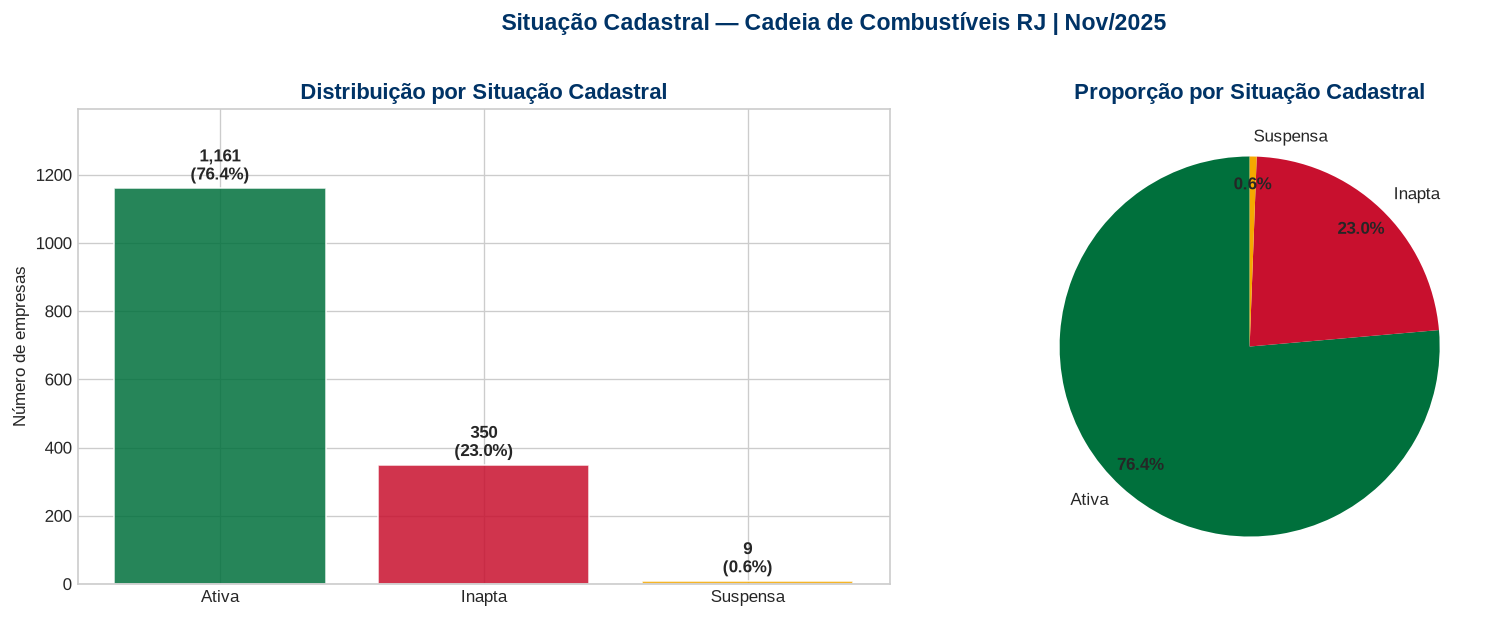

⚠️ Nota: 23% de empresas inaptas é elevado para um setor regulado pela ANP


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sit_counts = df['situacao_desc'].value_counts()
cores_sit = [CORES['verde'], CORES['vermelho'], CORES['amarelo']]
bars = axes[0].bar(sit_counts.index, sit_counts.values,
                    color=cores_sit, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, sit_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribuição por Situação Cadastral')
axes[0].set_ylabel('Número de empresas')
axes[0].set_ylim(0, sit_counts.max() * 1.2)

# Gráfico de pizza
wedges, texts, autotexts = axes[1].pie(
    sit_counts.values,
    labels=sit_counts.index,
    colors=cores_sit,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontweight('bold')
axes[1].set_title('Proporção por Situação Cadastral')

plt.suptitle('Situação Cadastral — Cadeia de Combustíveis RJ | Nov/2025',
             fontsize=14, fontweight='bold', color=CORES['azul'], y=1.02)
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_01_situacao_cadastral.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('⚠️ Nota: 23% de empresas inaptas é elevado para um setor regulado pela ANP')

## 4. Análise por Segmento (CNAE)

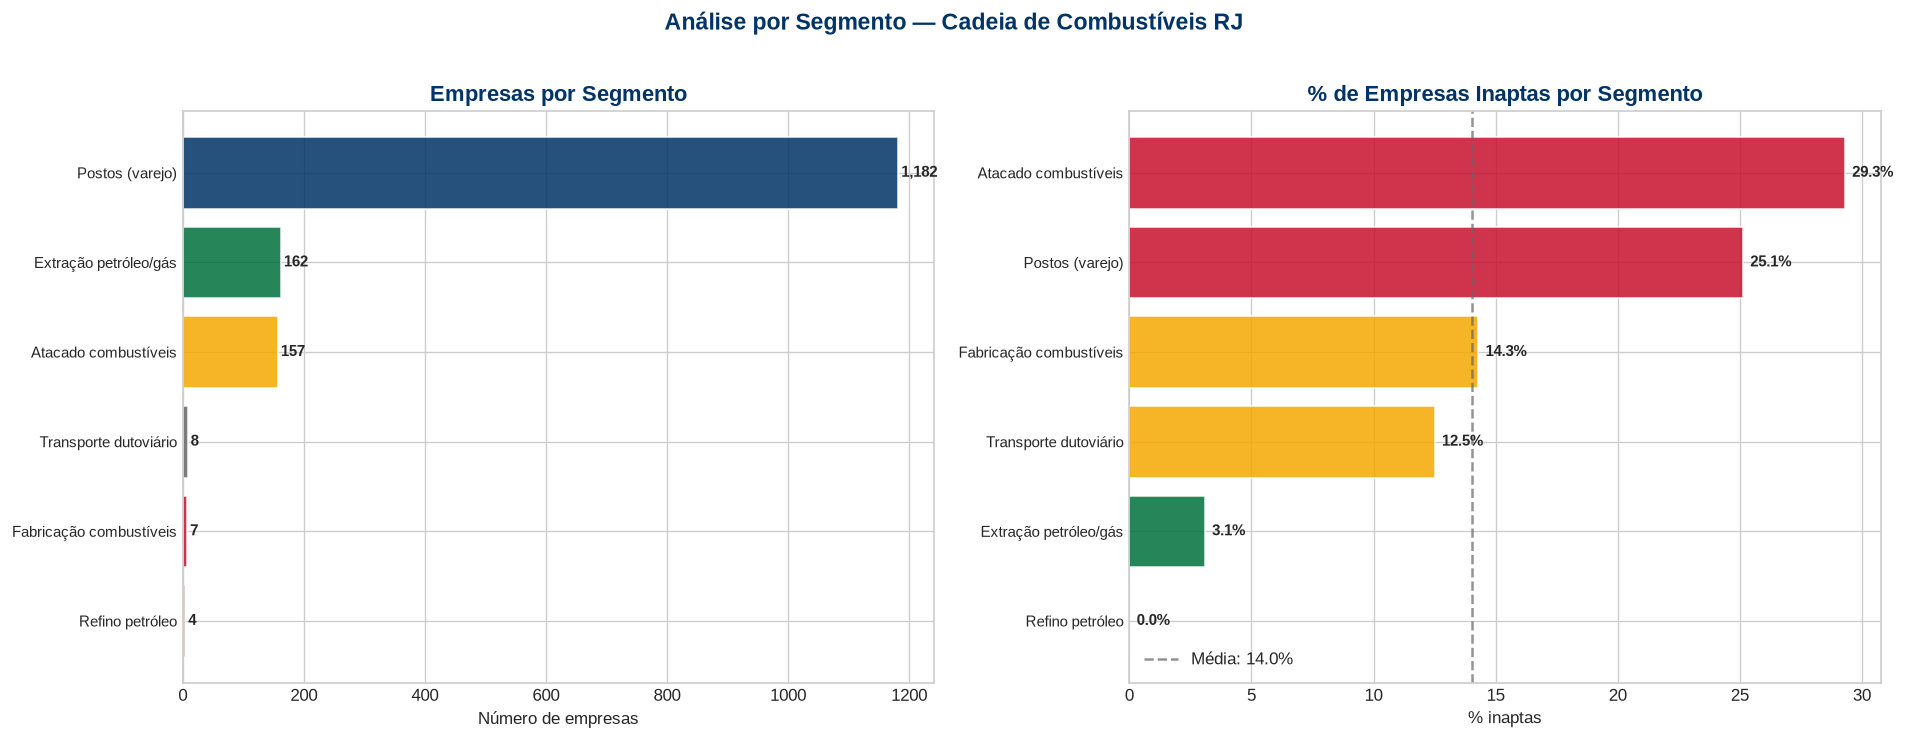

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total por segmento
cnae_counts = df['cnae_descricao'].value_counts()
# Abreviar nomes longos
nomes_curtos = {
    'Comércio varejista de combustíveis (postos)': 'Postos (varejo)',
    'Extração de petróleo e gás natural': 'Extração petróleo/gás',
    'Comércio atacadista de combustíveis': 'Atacado combustíveis',
    'Transporte dutoviário de combustíveis': 'Transporte dutoviário',
    'Fabricação de combustíveis': 'Fabricação combustíveis',
    'Fabricação de produtos do refino de petróleo': 'Refino petróleo',
}
cnae_counts.index = [nomes_curtos.get(i, i) for i in cnae_counts.index]

cores_cnae = [CORES['azul'], CORES['verde'], CORES['amarelo'],
              CORES['cinza'], CORES['vermelho'], '#8B4513']
bars = axes[0].barh(range(len(cnae_counts)), cnae_counts.values,
                     color=cores_cnae[:len(cnae_counts)], alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(len(cnae_counts)))
axes[0].set_yticklabels(cnae_counts.index, fontsize=9)
axes[0].invert_yaxis()
for bar, val in zip(bars, cnae_counts.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Empresas por Segmento')
axes[0].set_xlabel('Número de empresas')

# % inaptas por segmento
inaptas_cnae = df.groupby('cnae_descricao').apply(
    lambda x: (x['situacao_desc'] == 'Inapta').mean() * 100
).sort_values(ascending=True)
inaptas_cnae.index = [nomes_curtos.get(i, i) for i in inaptas_cnae.index]

cores_inap = [CORES['vermelho'] if v > 20 else CORES['amarelo']
              if v > 10 else CORES['verde'] for v in inaptas_cnae.values]
bars2 = axes[1].barh(range(len(inaptas_cnae)), inaptas_cnae.values,
                      color=cores_inap, alpha=0.85, edgecolor='white')
axes[1].set_yticks(range(len(inaptas_cnae)))
axes[1].set_yticklabels(inaptas_cnae.index, fontsize=9)
axes[1].axvline(x=inaptas_cnae.mean(), color=CORES['cinza'],
                linestyle='--', alpha=0.7, label=f'Média: {inaptas_cnae.mean():.1f}%')
for bar, val in zip(bars2, inaptas_cnae.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('% de Empresas Inaptas por Segmento')
axes[1].set_xlabel('% inaptas')
axes[1].legend()

plt.suptitle('Análise por Segmento — Cadeia de Combustíveis RJ',
             fontsize=14, fontweight='bold', color=CORES['azul'], y=1.02)
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_02_analise_segmento.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise Societária

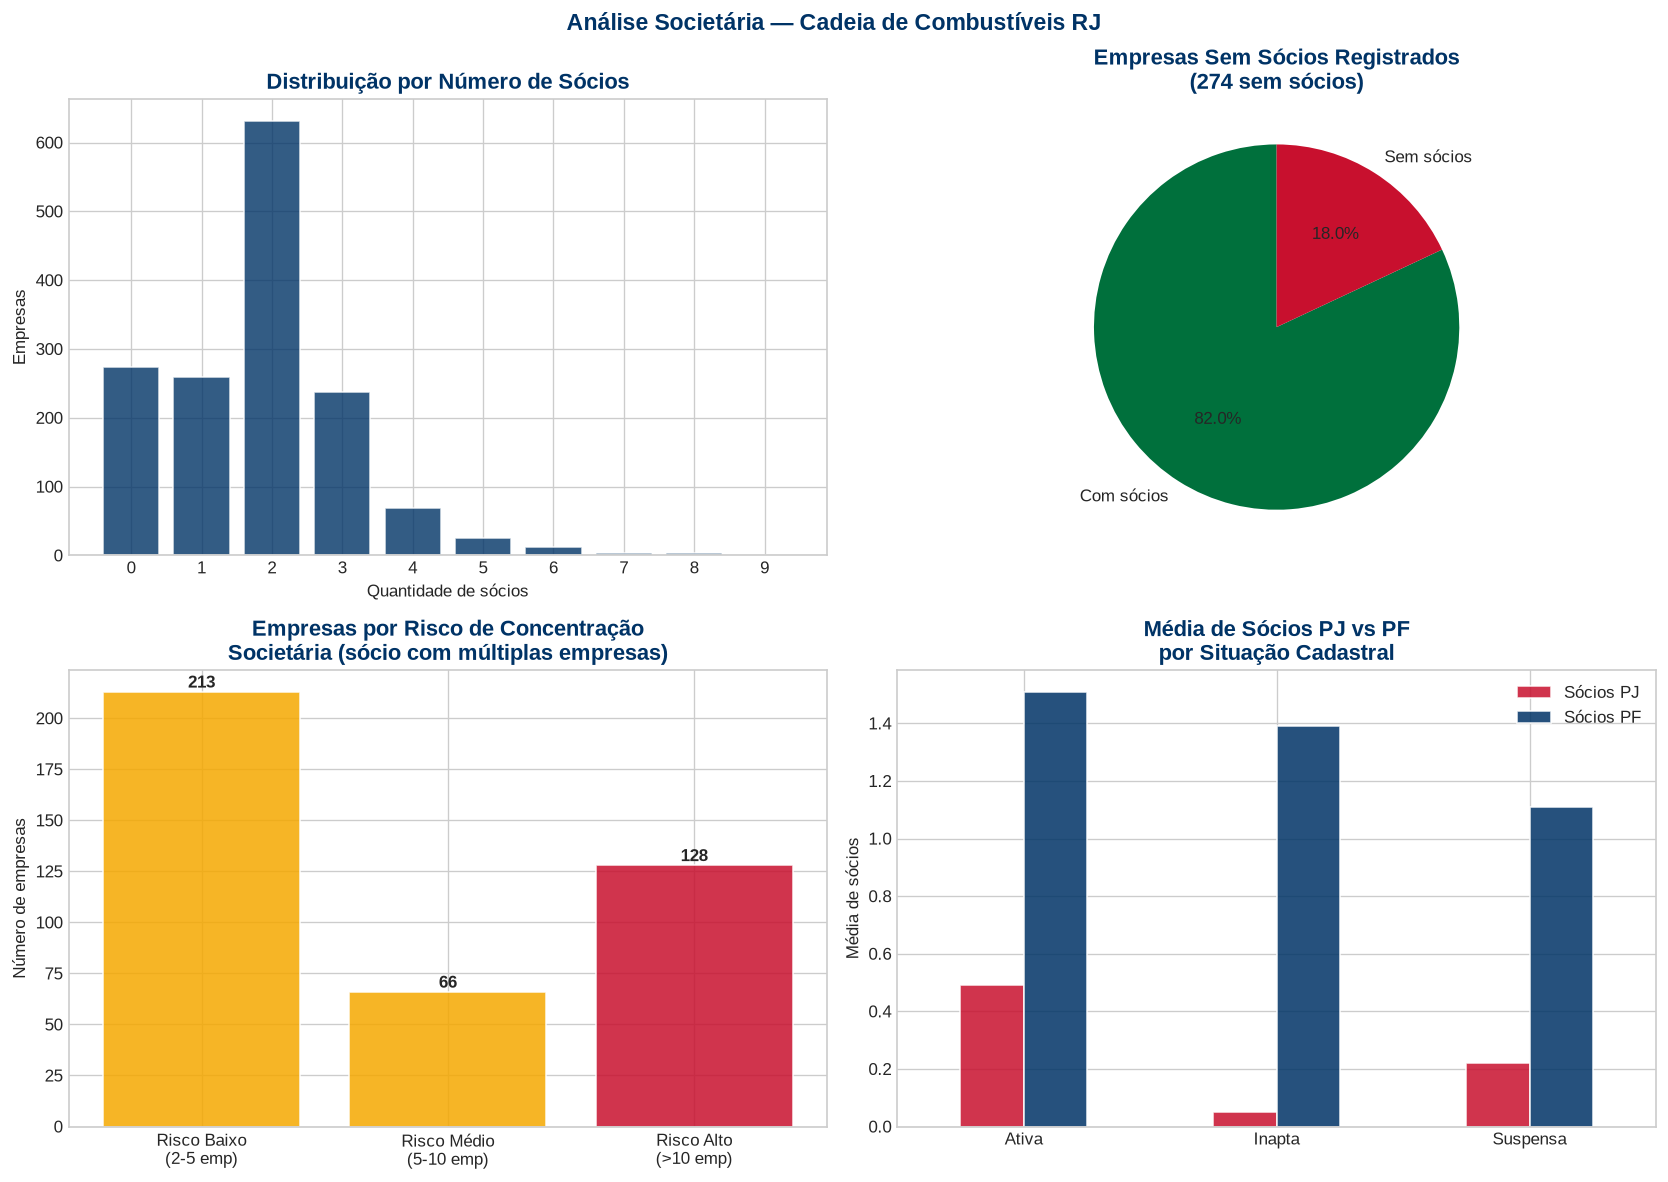


📊 Insights societários:
  • 274 empresas sem sócios registrados (18.0%)
  • 128 empresas com sócio em >10 empresas
  • 194 empresas com sócio em >5 empresas


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Distribuição de sócios
socios_dist = df['qtd_socios'].value_counts().sort_index().head(10)
axes[0,0].bar(socios_dist.index, socios_dist.values,
               color=CORES['azul'], alpha=0.8, edgecolor='white')
axes[0,0].set_title('Distribuição por Número de Sócios')
axes[0,0].set_xlabel('Quantidade de sócios')
axes[0,0].set_ylabel('Empresas')
axes[0,0].set_xticks(socios_dist.index)

# 5.2 Empresas sem sócios
sem_socios = df['sem_socios'].value_counts()
labels_ss = ['Com sócios', 'Sem sócios']
cores_ss = [CORES['verde'], CORES['vermelho']]
axes[0,1].pie([sem_socios.get(0, 0), sem_socios.get(1, 0)],
               labels=labels_ss, colors=cores_ss,
               autopct='%1.1f%%', startangle=90)
axes[0,1].set_title(f'Empresas Sem Sócios Registrados\n({sem_socios.get(1,0):,} sem sócios)')

# 5.3 Risco por concentração de sócios
risco_socios = pd.DataFrame({
    'Categoria': ['Risco Baixo\n(2-5 emp)', 'Risco Médio\n(5-10 emp)', 'Risco Alto\n(>10 emp)'],
    'Qtd': [df['socio_risco_baixo'].sum(),
            df['socio_risco_medio'].sum(),
            df['socio_risco_alto'].sum()]
})
cores_rs = [CORES['amarelo'], CORES['amarelo'], CORES['vermelho']]
bars = axes[1,0].bar(risco_socios['Categoria'], risco_socios['Qtd'],
                      color=cores_rs, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, risco_socios['Qtd']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 2,
                   f'{val:,}', ha='center', fontweight='bold')
axes[1,0].set_title('Empresas por Risco de Concentração\nSocietária (sócio com múltiplas empresas)')
axes[1,0].set_ylabel('Número de empresas')

# 5.4 Tipo de sócio por situação
tipo_sit = df.groupby('situacao_desc')[['qtd_socios_pj', 'qtd_socios_pf']].mean().round(2)
tipo_sit.plot(kind='bar', ax=axes[1,1],
              color=[CORES['vermelho'], CORES['azul']],
              alpha=0.85, edgecolor='white')
axes[1,1].set_title('Média de Sócios PJ vs PF\npor Situação Cadastral')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Média de sócios')
axes[1,1].legend(['Sócios PJ', 'Sócios PF'])
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Análise Societária — Cadeia de Combustíveis RJ',
             fontsize=14, fontweight='bold', color=CORES['azul'])
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_03_analise_societaria.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Insights societários:')
print(f'  • {df["sem_socios"].sum():,} empresas sem sócios registrados ({df["sem_socios"].mean()*100:.1f}%)')
print(f'  • {df["socio_risco_alto"].sum():,} empresas com sócio em >10 empresas')
print(f'  • {df["socio_multiplas_empresas"].sum():,} empresas com sócio em >5 empresas')

## 6. Análise Financeira (Capital Social)

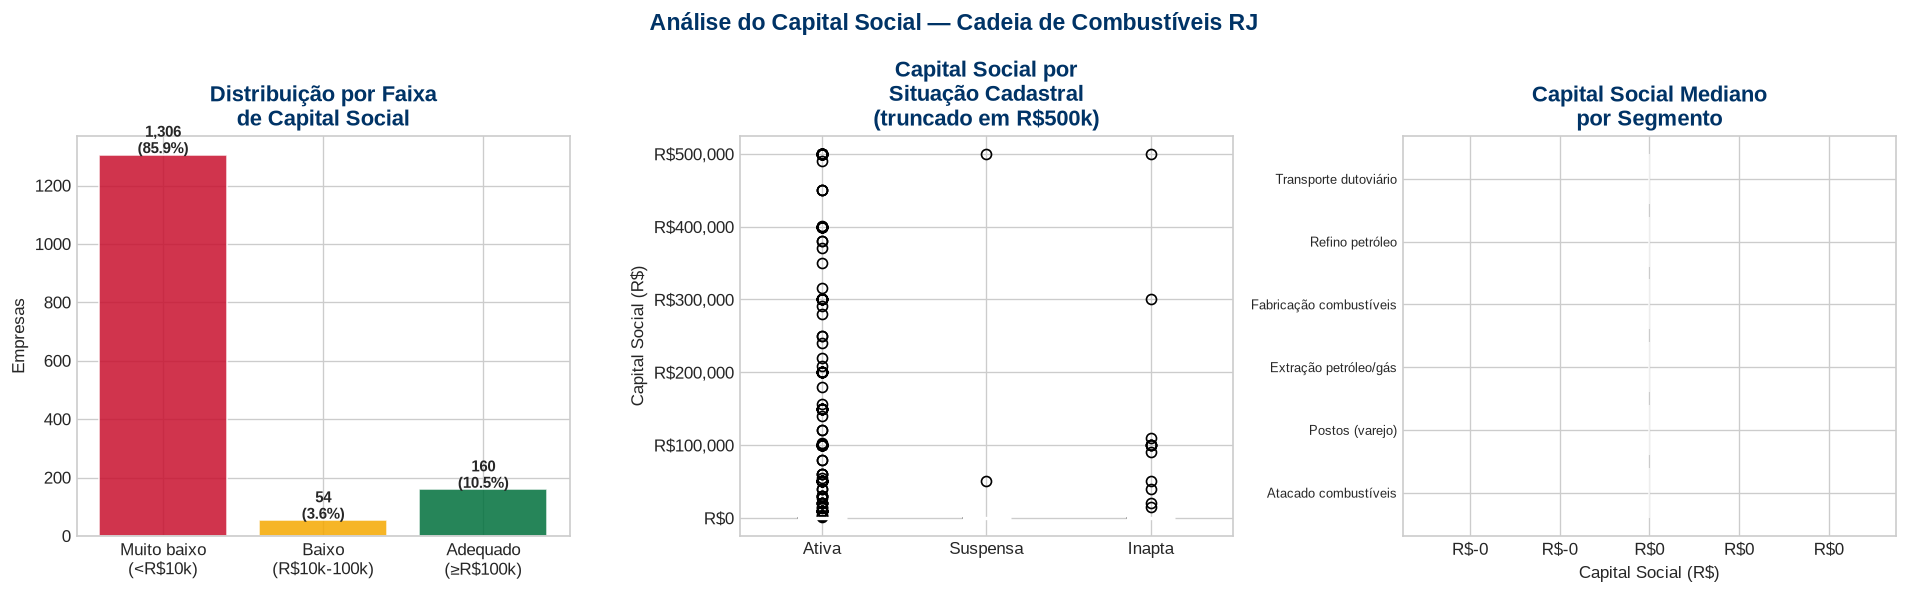


📊 Insights financeiros:
  • 85.9% das empresas têm capital < R$10.000
  • Capital mediano geral: R$0.00
  • Capital médio geral:   R$4,378,715.57


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6.1 Faixas de capital
faixas = pd.Series({
    'Muito baixo\n(<R$10k)':   df['capital_muito_baixo'].sum(),
    'Baixo\n(R$10k-100k)':     df['capital_baixo'].sum(),
    'Adequado\n(≥R$100k)':     df['capital_adequado'].sum(),
})
cores_cap = [CORES['vermelho'], CORES['amarelo'], CORES['verde']]
bars = axes[0].bar(faixas.index, faixas.values,
                    color=cores_cap, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, faixas.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribuição por Faixa\nde Capital Social')
axes[0].set_ylabel('Empresas')

# 6.2 Capital por situação cadastral (excluindo outliers extremos)
cap_clip = df['capital_social'].clip(upper=500_000)
df_plot = df.copy()
df_plot['capital_clip'] = cap_clip
ordem_sit = ['Ativa', 'Suspensa', 'Inapta']
dados_box = [df_plot[df_plot['situacao_desc'] == s]['capital_clip'].values
             for s in ordem_sit]
bp = axes[1].boxplot(dados_box, tick_labels=ordem_sit, patch_artist=True,
                      medianprops={'color': 'white', 'linewidth': 2})
cores_box = [CORES['verde'], CORES['amarelo'], CORES['vermelho']]
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].set_title('Capital Social por\nSituação Cadastral\n(truncado em R$500k)')
axes[1].set_ylabel('Capital Social (R$)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

# 6.3 Capital por segmento
cap_cnae = df.groupby('cnae_descricao')['capital_social'].median().sort_values()
cap_cnae.index = [nomes_curtos.get(i, i[:20]) for i in cap_cnae.index]
axes[2].barh(range(len(cap_cnae)), cap_cnae.values,
              color=CORES['azul'], alpha=0.8, edgecolor='white')
axes[2].set_yticks(range(len(cap_cnae)))
axes[2].set_yticklabels(cap_cnae.index, fontsize=8)
axes[2].set_title('Capital Social Mediano\npor Segmento')
axes[2].set_xlabel('Capital Social (R$)')
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

plt.suptitle('Análise do Capital Social — Cadeia de Combustíveis RJ',
             fontsize=14, fontweight='bold', color=CORES['azul'])
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_04_capital_social.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Insights financeiros:')
print(f'  • {df["capital_muito_baixo"].mean()*100:.1f}% das empresas têm capital < R$10.000')
print(f'  • Capital mediano geral: R${df["capital_social"].median():,.2f}')
print(f'  • Capital médio geral:   R${df["capital_social"].mean():,.2f}')

## 7. Análise Temporal

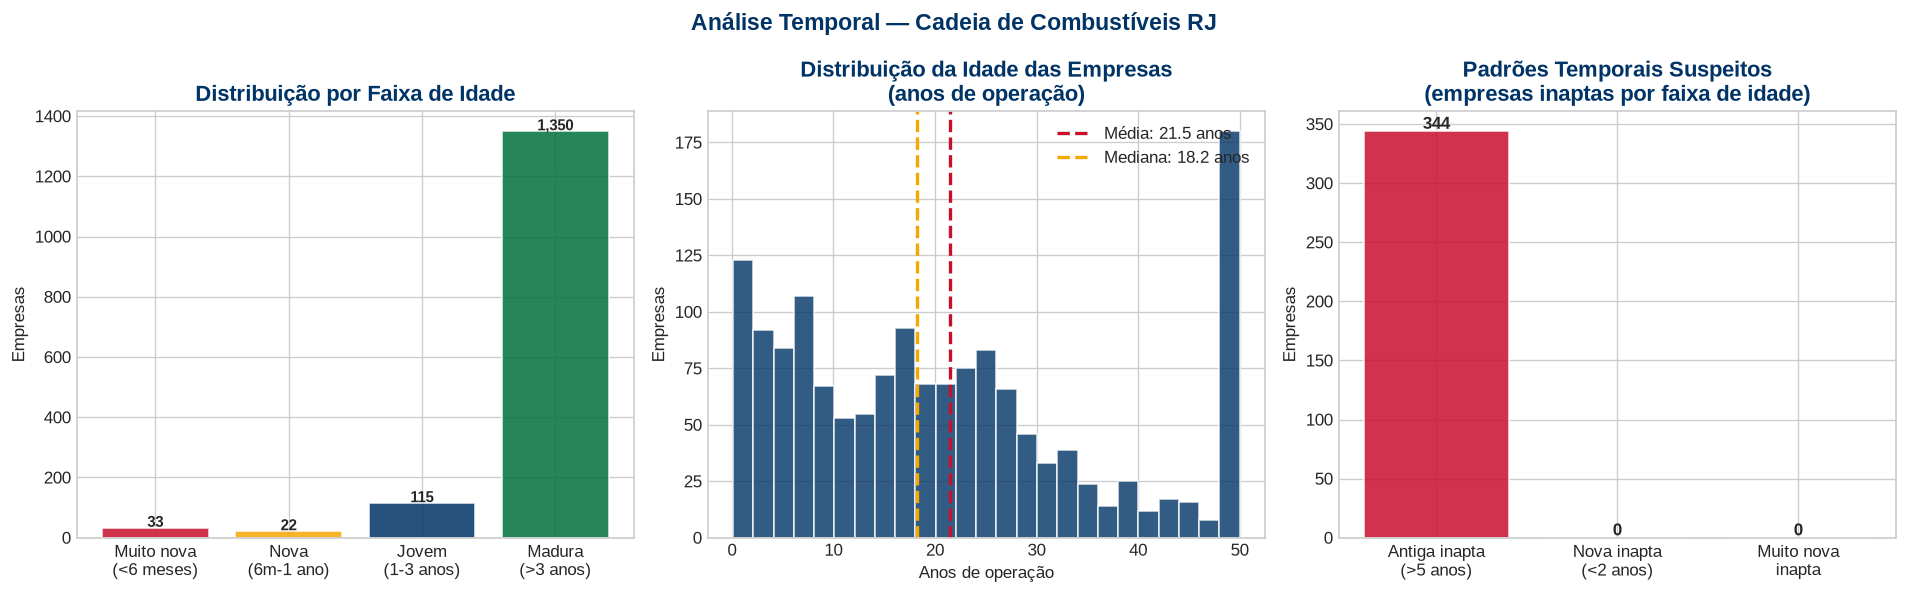


📊 Insights temporais:
  • 344 empresas com >5 anos de operação e inaptas
  • 33 empresas abertas há menos de 6 meses
  • Idade média do setor: 21.5 anos


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7.1 Faixas de idade
faixas_idade = pd.Series({
    'Muito nova\n(<6 meses)':  df['empresa_muito_nova'].sum(),
    'Nova\n(6m-1 ano)':        df['empresa_nova'].sum(),
    'Jovem\n(1-3 anos)':       df['empresa_jovem'].sum(),
    'Madura\n(>3 anos)':       df['empresa_madura'].sum(),
})
cores_idade = [CORES['vermelho'], CORES['amarelo'],
               CORES['azul'], CORES['verde']]
bars = axes[0].bar(faixas_idade.index, faixas_idade.values,
                    color=cores_idade, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, faixas_idade.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Distribuição por Faixa de Idade')
axes[0].set_ylabel('Empresas')

# 7.2 Histograma de anos de operação
axes[1].hist(df['anos_operacao'].clip(upper=50), bins=25,
              color=CORES['azul'], edgecolor='white', alpha=0.8)
axes[1].axvline(df['anos_operacao'].mean(), color=CORES['vermelho'],
                linestyle='--', linewidth=2,
                label=f'Média: {df["anos_operacao"].mean():.1f} anos')
axes[1].axvline(df['anos_operacao'].median(), color=CORES['amarelo'],
                linestyle='--', linewidth=2,
                label=f'Mediana: {df["anos_operacao"].median():.1f} anos')
axes[1].set_title('Distribuição da Idade das Empresas\n(anos de operação)')
axes[1].set_xlabel('Anos de operação')
axes[1].set_ylabel('Empresas')
axes[1].legend()

# 7.3 Inaptas antigas vs novas
padroes = pd.Series({
    'Antiga inapta\n(>5 anos)': df['antiga_inapta'].sum(),
    'Nova inapta\n(<2 anos)':   df['nova_inapta'].sum(),
    'Muito nova\ninapta':        ((df['empresa_muito_nova']==1) &
                                   (df['inapta']==1)).sum(),
})
axes[2].bar(padroes.index, padroes.values,
             color=[CORES['vermelho'], CORES['amarelo'], CORES['cinza']],
             alpha=0.85, edgecolor='white')
for i, (label, val) in enumerate(padroes.items()):
    axes[2].text(i, val + 2, f'{val:,}',
                  ha='center', fontweight='bold')
axes[2].set_title('Padrões Temporais Suspeitos\n(empresas inaptas por faixa de idade)')
axes[2].set_ylabel('Empresas')

plt.suptitle('Análise Temporal — Cadeia de Combustíveis RJ',
             fontsize=14, fontweight='bold', color=CORES['azul'])
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_05_analise_temporal.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Insights temporais:')
print(f'  • {df["antiga_inapta"].sum():,} empresas com >5 anos de operação e inaptas')
print(f'  • {df["empresa_muito_nova"].sum():,} empresas abertas há menos de 6 meses')
print(f'  • Idade média do setor: {df["anos_operacao"].mean():.1f} anos')

## 8. Correlações entre Variáveis

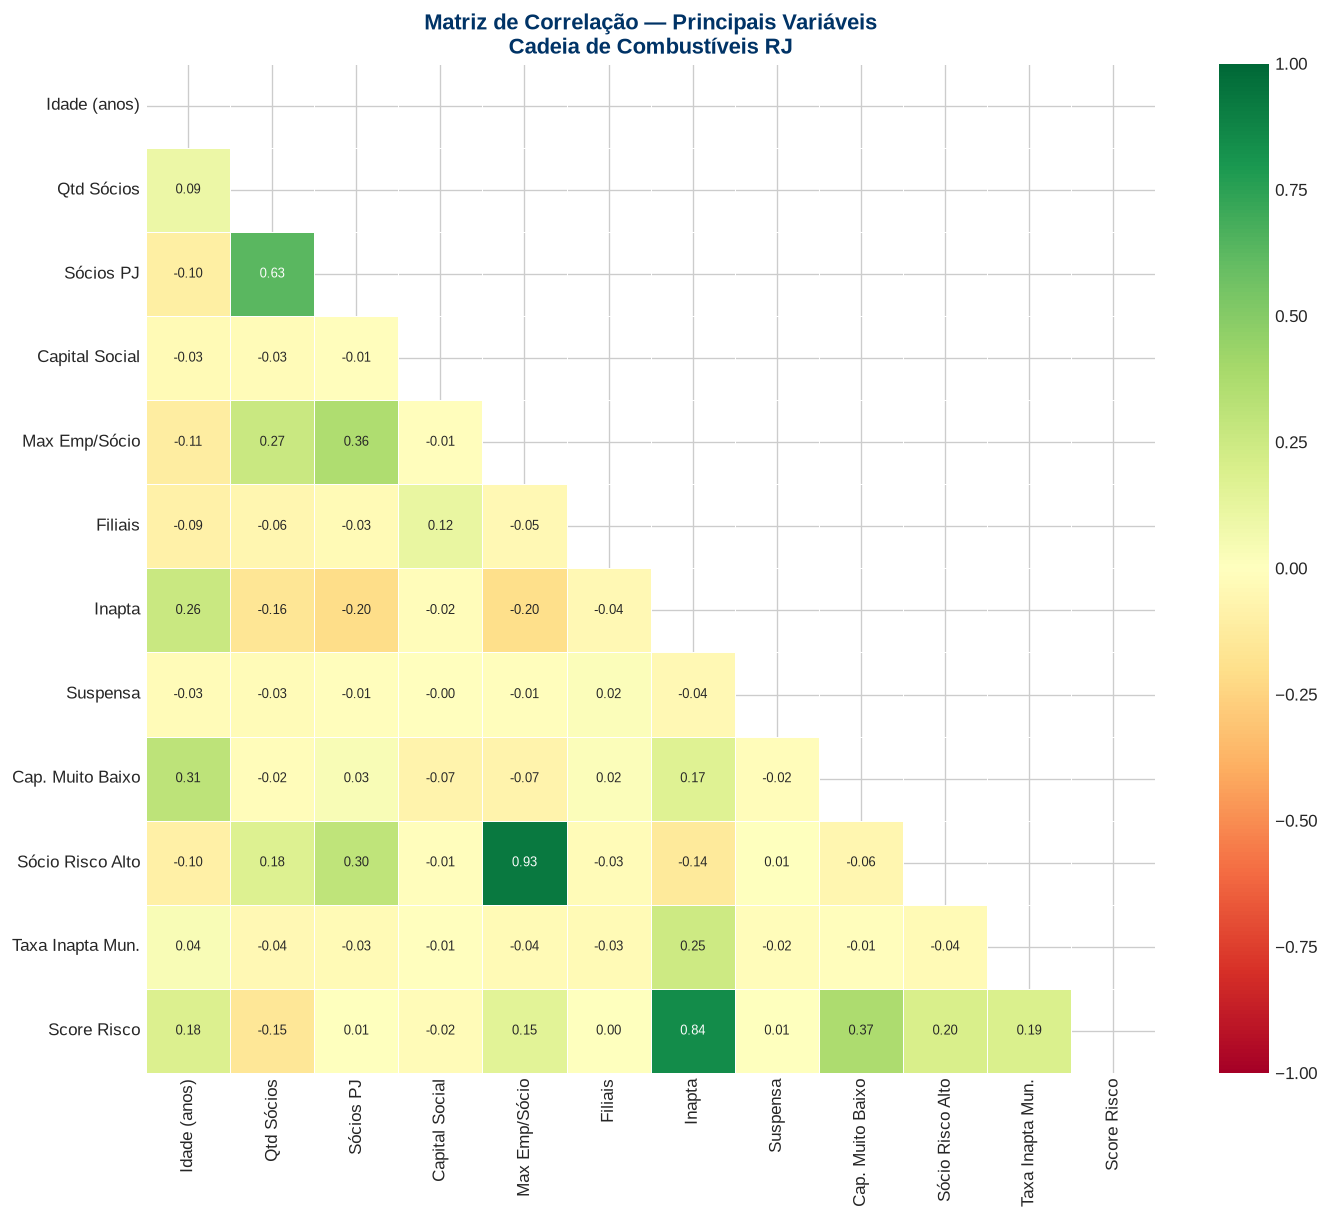


📊 Correlação das variáveis com o Score de Risco:
Qtd Sócios         -0.149366
Capital Social     -0.023645
Filiais             0.000900
Sócios PJ           0.005890
Suspensa            0.006815
Max Emp/Sócio       0.149718
Idade (anos)        0.184857
Taxa Inapta Mun.    0.189128
Sócio Risco Alto    0.197536
Cap. Muito Baixo    0.367234
Inapta              0.844689


In [11]:
# Selecionar variáveis mais relevantes para a correlação
cols_corr = [
    'anos_operacao', 'qtd_socios', 'qtd_socios_pj',
    'capital_social', 'max_empresas_por_socio',
    'qtd_filiais', 'inapta', 'suspensa',
    'capital_muito_baixo', 'socio_risco_alto',
    'taxa_inapta_municipio', 'score_risco_v2'
]
cols_corr = [c for c in cols_corr if c in df.columns]

nomes_legenda = {
    'anos_operacao': 'Idade (anos)',
    'qtd_socios': 'Qtd Sócios',
    'qtd_socios_pj': 'Sócios PJ',
    'capital_social': 'Capital Social',
    'max_empresas_por_socio': 'Max Emp/Sócio',
    'qtd_filiais': 'Filiais',
    'inapta': 'Inapta',
    'suspensa': 'Suspensa',
    'capital_muito_baixo': 'Cap. Muito Baixo',
    'socio_risco_alto': 'Sócio Risco Alto',
    'taxa_inapta_municipio': 'Taxa Inapta Mun.',
    'score_risco_v2': 'Score Risco'
}

corr = df[cols_corr].rename(columns=nomes_legenda).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title('Matriz de Correlação — Principais Variáveis\nCadeia de Combustíveis RJ',
             fontsize=13, fontweight='bold', color=CORES['azul'])
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_06_correlacao.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Correlações com o score de risco
corr_score = corr['Score Risco'].drop('Score Risco').sort_values()
print('\n📊 Correlação das variáveis com o Score de Risco:')
print(corr_score.to_string())

## 9. Análise do Score de Risco

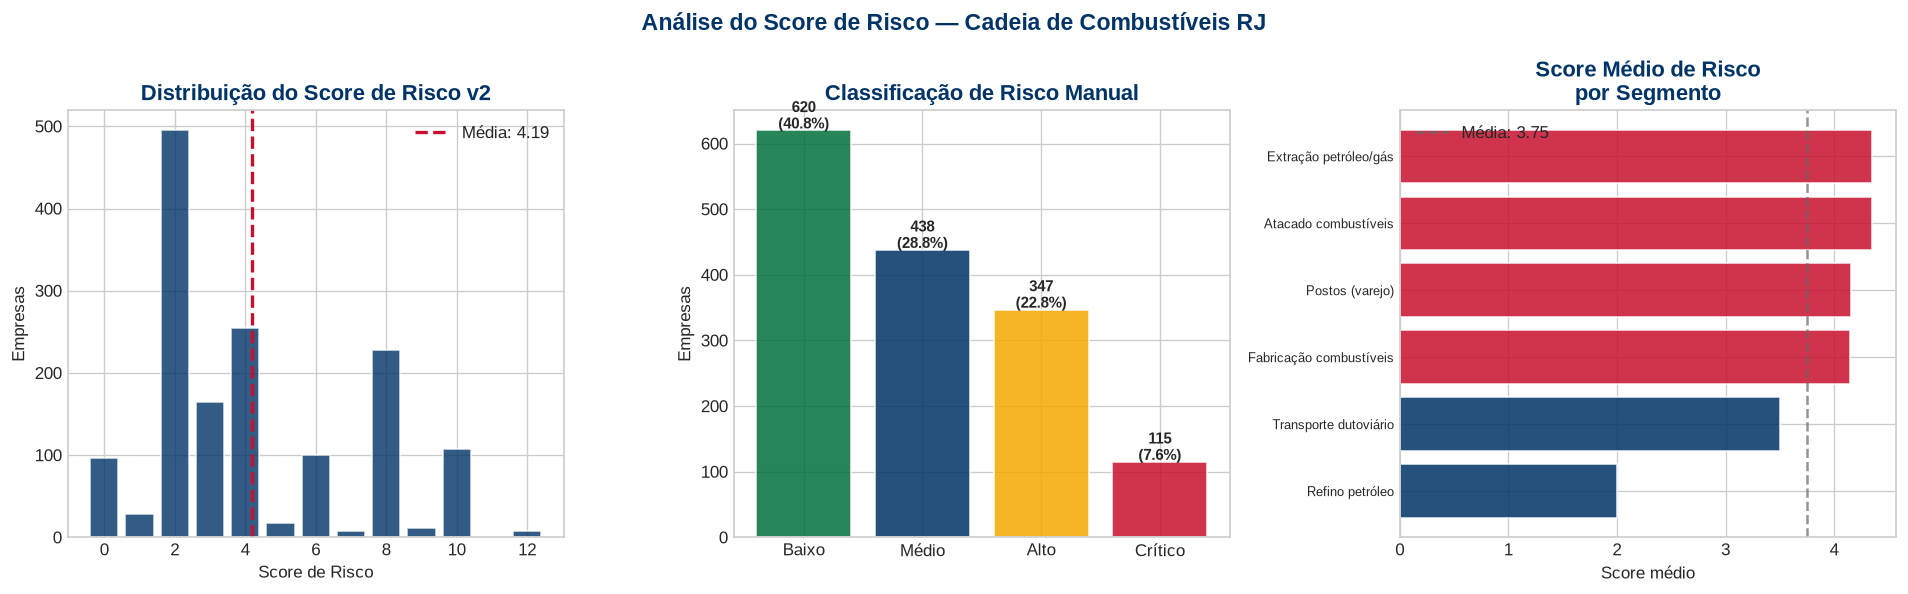

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 9.1 Distribuição do score
score_counts = df['score_risco_v2'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
             color=CORES['azul'], alpha=0.8, edgecolor='white')
axes[0].axvline(df['score_risco_v2'].mean(), color=CORES['vermelho'],
                linestyle='--', linewidth=2,
                label=f'Média: {df["score_risco_v2"].mean():.2f}')
axes[0].set_title('Distribuição do Score de Risco v2')
axes[0].set_xlabel('Score de Risco')
axes[0].set_ylabel('Empresas')
axes[0].legend()

# 9.2 Score por classe
classe_counts = df['classe_risco'].value_counts()
ordem_classe = ['Baixo', 'Médio', 'Alto', 'Crítico']
classe_counts = classe_counts.reindex(
    [c for c in ordem_classe if c in classe_counts.index]
)
cores_classe = [CORES_RISCO.get(c, CORES['cinza'])
                for c in classe_counts.index]
bars = axes[1].bar(classe_counts.index, classe_counts.values,
                    color=cores_classe, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, classe_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Classificação de Risco Manual')
axes[1].set_ylabel('Empresas')

# 9.3 Score médio por segmento
score_cnae = df.groupby('cnae_descricao')['score_risco_v2'].mean().sort_values()
score_cnae.index = [nomes_curtos.get(i, i[:20]) for i in score_cnae.index]
cores_score = [CORES['vermelho'] if v > score_cnae.mean()
               else CORES['azul'] for v in score_cnae.values]
axes[2].barh(range(len(score_cnae)), score_cnae.values,
              color=cores_score, alpha=0.85, edgecolor='white')
axes[2].set_yticks(range(len(score_cnae)))
axes[2].set_yticklabels(score_cnae.index, fontsize=8)
axes[2].axvline(score_cnae.mean(), color=CORES['cinza'],
                linestyle='--', alpha=0.7,
                label=f'Média: {score_cnae.mean():.2f}')
axes[2].set_title('Score Médio de Risco\npor Segmento')
axes[2].set_xlabel('Score médio')
axes[2].legend()

plt.suptitle('Análise do Score de Risco — Cadeia de Combustíveis RJ',
             fontsize=14, fontweight='bold', color=CORES['azul'])
plt.tight_layout()
plt.savefig('../outputs/graficos/EDA_07_score_risco.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 10. Síntese dos Achados

In [13]:
print('=' * 65)
print('  SÍNTESE DA ANÁLISE EXPLORATÓRIA')
print('  Cadeia de Combustíveis RJ | Nov/2025')
print('=' * 65)

print('\n📌 PERFIL GERAL:')
print(f'  • {len(df):,} empresas analisadas em 6 segmentos da cadeia')
print(f'  • Postos de varejo dominam com {(df["cnae_4dig"]=="4731").sum():,} unidades ({(df["cnae_4dig"]=="4731").mean()*100:.1f}%)')
print(f'  • Idade média de {df["anos_operacao"].mean():.1f} anos de operação')

print('\n⚠️ INDICADORES DE ANOMALIA:')
print(f'  • {df["inapta"].mean()*100:.1f}% das empresas estão inaptas (benchmark esperado: <5%)')
print(f'  • {df["capital_muito_baixo"].mean()*100:.1f}% têm capital < R$10.000 — incompatível com o setor')
print(f'  • {df["sem_socios"].mean()*100:.1f}% não possuem sócios registrados')
print(f'  • {df["socio_risco_alto"].mean()*100:.1f}% têm sócio com mais de 10 empresas no nome')

print('\n🔍 PADRÕES TEMPORAIS:')
print(f'  • {df["antiga_inapta"].sum():,} empresas inaptas há mais de 5 anos — abandono ou fraude histórica')
print(f'  • {df["empresa_muito_nova"].sum():,} empresas abertas há menos de 6 meses')

print('\n📊 SCORE DE RISCO:')
print(f'  • Score médio: {df["score_risco_v2"].mean():.2f} (escala 0-12)')
for classe in ['Baixo', 'Médio', 'Alto', 'Crítico']:
    qtd = (df['classe_risco'] == classe).sum()
    print(f'  • {classe:<10}: {qtd:>5,} empresas ({qtd/len(df)*100:.1f}%)')

print('\n✅ CONCLUSÃO:')
print('  Os dados revelam um setor com alto grau de irregularidade')
print('  cadastral. A combinação de capital irrisório, situação inapta')
print('  e estrutura societária suspeita justifica a aplicação de')
print('  técnicas de detecção de anomalias (Isolation Forest + DBSCAN)')
print('  para identificar empresas com maior risco de fraude fiscal.')
print('=' * 65)

  SÍNTESE DA ANÁLISE EXPLORATÓRIA
  Cadeia de Combustíveis RJ | Nov/2025

📌 PERFIL GERAL:
  • 1,520 empresas analisadas em 6 segmentos da cadeia
  • Postos de varejo dominam com 1,182 unidades (77.8%)
  • Idade média de 21.5 anos de operação

⚠️ INDICADORES DE ANOMALIA:
  • 23.0% das empresas estão inaptas (benchmark esperado: <5%)
  • 85.9% têm capital < R$10.000 — incompatível com o setor
  • 18.0% não possuem sócios registrados
  • 8.4% têm sócio com mais de 10 empresas no nome

🔍 PADRÕES TEMPORAIS:
  • 344 empresas inaptas há mais de 5 anos — abandono ou fraude histórica
  • 33 empresas abertas há menos de 6 meses

📊 SCORE DE RISCO:
  • Score médio: 4.19 (escala 0-12)
  • Baixo     :   620 empresas (40.8%)
  • Médio     :   438 empresas (28.8%)
  • Alto      :   347 empresas (22.8%)
  • Crítico   :   115 empresas (7.6%)

✅ CONCLUSÃO:
  Os dados revelam um setor com alto grau de irregularidade
  cadastral. A combinação de capital irrisório, situação inapta
  e estrutura societária s